# Stage 4 — Cluster Analysis (Human-in-the-Loop)

**Input**: `adata.h5ad`, dot plot, heatmap, `top_markers.csv` from Stage 3  
**Output**: `cluster_labels.csv` (cluster_id, label, group)  
**Scope**: Per machine — interactive labelling and grouping of clusters.

Review the Stage 3 visualisations, then use the widget below to assign a **cell-type label** and **group** to each cluster.

In [1]:
import pandas as pd
from IPython.display import display, Image as IPImage, SVG
from pathlib import Path

from pipeline.config import load_config
from pipeline.io import load_adata, save_cluster_labels, load_cluster_labels, validate_stage_inputs
from pipeline.widgets import create_cluster_label_widget

cfg = load_config("config.yaml")

In [ ]:
# ── Select machine ──
MACHINE = list(cfg.machines.keys())[1]
print(f"Available machines: {list(cfg.machines.keys())}")
print(f"Selected: {MACHINE}")

stage3_dir = cfg.stage_dir(3, MACHINE)
stage4_dir = cfg.ensure_stage_dir(4, MACHINE)

# Validate Stage 3 outputs exist
validate_stage_inputs(
    [stage3_dir / "adata.h5ad", stage3_dir / "top_markers.csv"],
    "Stage 4",
)

Available machines: ['machine_A', 'machine_B']
Selected: machine_A
[Stage 4] All required inputs found ✓


## Review Stage 3 Results

Examine the dot plot, heatmap, and top markers to inform your cluster labelling.

Clusters found: ['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '4', '5', '6', '7', '8', '9']

Top markers per cluster:


/home/hp/projects/multiplex_imaging_analysis/.venv/lib/python3.10/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


,group,names,scores,logfoldchanges,pvals,pvals_adj
0,0,CD4 REA1307,-99.449646,3.919413,0.000000e+00,0.000000e+00
1,0,Podoplanin REA446,73.098600,3.369508,0.000000e+00,0.000000e+00
2,0,FoxP3 REA1253,8.903811,0.065496,5.396127e-19,5.865356e-19
3,0,CD20 REAL1069,18.110952,-1.099792,2.611920e-73,3.109428e-73
4,0,Mast Cell Tryptase REAL798,2.353658,-2.037962,1.858972e-02,1.858972e-02
...,...,...,...,...,...,...
160,32,Podoplanin REA446,18.719320,10.359033,3.445139e-78,8.612849e-77
161,32,CD73 REAL1172,-0.835396,4.767499,4.034949e-01,4.585169e-01
162,32,CD3 REAL1097,0.278747,4.698185,7.804391e-01,8.129574e-01
163,32,PAX 5 REA140,-1.404972,4.501320,1.600296e-01,2.105652e-01



--- dotplot.svg ---


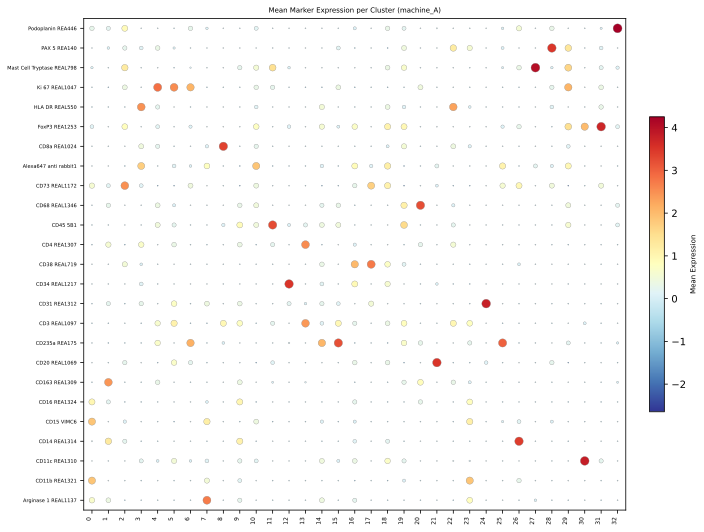


--- heatmap.svg ---


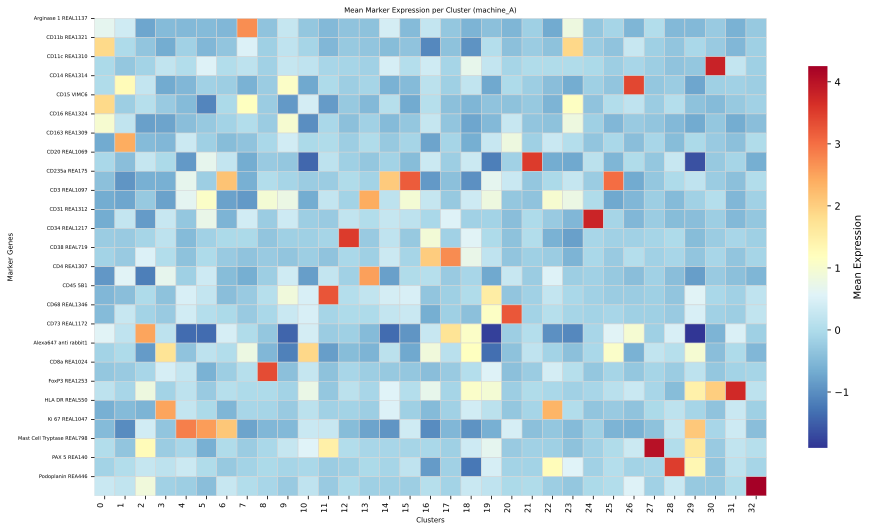

In [3]:
# Load Stage 3 outputs
adata = load_adata(stage3_dir / "adata.h5ad")
top_markers = pd.read_csv(stage3_dir / "top_markers.csv")

print(f"Clusters found: {sorted(adata.obs['leiden'].unique().tolist())}")
print(f"\nTop markers per cluster:")
display(top_markers)

# Display saved plots
for plot_name in ["dotplot.svg", "heatmap.svg"]:
    plot_path = stage3_dir / plot_name
    if plot_path.exists():
        print(f"\n--- {plot_name} ---")
        display(SVG(filename=str(plot_path)))

## Assign Cluster Labels & Groups

For each cluster:
- **Label**: The cell-type name (e.g., "CD8 T Cell", "Macrophage")
- **Group**: A category for pooling (e.g., "T Cells", "Myeloid"). Clusters sharing the same group will be merged in Stage 5.

If you leave Group empty, it defaults to the Label.

In [4]:
cluster_ids = sorted(adata.obs["leiden"].unique().tolist(), key=lambda x: int(x) if x.isdigit() else x)

# Pre-load existing labels if available (edit mode)
labels_path = stage4_dir / "cluster_labels.csv"
existing_labels = None
if labels_path.exists():
    existing_labels = load_cluster_labels(labels_path)
    print(f"✎ Loaded existing labels from {labels_path} — editing mode")
else:
    print("No existing labels found — starting fresh")

# Save callback
def save_labels(df):
    save_cluster_labels(df, labels_path)

widget = create_cluster_label_widget(cluster_ids, save_callback=save_labels, existing_labels=existing_labels)
display(widget)

No existing labels found — starting fresh


## Verify Saved Labels

Run this cell after clicking "Save Labels" above to confirm the output.

In [5]:
from pipeline.io import load_cluster_labels

labels_path = stage4_dir / "cluster_labels.csv"
if labels_path.exists():
    saved = load_cluster_labels(labels_path)
    display(saved)
    print(f"\n✓ Stage 4 complete for machine '{MACHINE}'")
    print(f"  Output: {labels_path}")
else:
    print("⚠ No labels saved yet. Use the widget above to assign labels, then click Save.")

,cluster_id,label,group
0,0,Granluocyte,Myeloid
1,1,Monocytes,Myeloid
2,2,MSC,MSC
3,3,NPM1-positive/Erythroid,Tumor/Erythroid
4,4,Erythroid,Tumor/Erythroid
5,5,Tumor,Tumor
6,6,Erythroid,Erythroid
7,7,Granulocyte,Myeloid
8,8,CD8 T cell,T cells
9,9,Monocytes/CD4+ T,Myeloid



✓ Stage 4 complete for machine 'machine_A'
  Output: experiments/exp-04-03-2026/stage4_analysis/machine_A/cluster_labels.csv
